# Retrain and compare the three recoveries

The companion to `three_way_comparison.ipynb`, which only *reads* checkpoints. This
one **trains** $\psi_\theta$ and $G_\theta$ from the cached sampler splits and then
reruns both comparisons on the nets it just produced.

| | prose name | plot label | recovery of $J$ |
|---|---|---|---|
| $J_1(x)=\langle x,w\rangle-\psi_\theta(w)-\tfrac12\|x\|^2$ | **LPN Iterative recovery** | Iterative | an inversion **per query** |
| $J_2(x)=G_\theta(x)-\tfrac12\|x\|^2$ | **One-shot recovery** | One-shot | one forward pass |
| $J_\theta$ | **Direct fit** | Direct fit | none — $J$ was fitted directly |

`J_theta` is **not** retrained here: it is `recover_tv.ipynb`'s shipped checkpoint,
reused unchanged so the direct fit stays exactly the object that notebook reports.
Only the two LPN networks are rebuilt.

**This notebook writes to tagged files.** `RUN_TAG` below keys the checkpoints and
`OUT_TAG` keys the figures and tables, so a run here **cannot overwrite** the shipped
`threeway_psi_*.pth`, `prior_recovery.png`, `threeway_psnr.csv` and friends. Clear
both tags deliberately if replacing the reported results is what you actually mean.

## Configuration

Start with `PRESET = "smoke"`. It trains both nets for 3000 steps and runs the
comparisons on a reduced eval set — about four minutes end to end — so a typo or a
missing file surfaces now rather than ninety minutes in. Switch to `"full"` once it
runs clean; only the full preset reproduces the reported numbers.

In [19]:
import os

PRESET = "full"          # "smoke" (~4 min total)  |  "full" (~3 h on 2 CPU cores)

RUN_TAG = "_retrain"      # checkpoint tag;  "" overwrites the shipped checkpoints
OUT_TAG = "_retrain"      # figure/table tag; "" overwrites the reported figures
FORCE   = False           # True: retrain even if a checkpoint for this tag exists

STEPS = {"smoke": 3_000, "full": 250_000}[PRESET]

# reported settings: 2000 patches, 20000 iterations.
N_EVAL, INVERT_ITERS = {"smoke": (300, 3_000), "full": (2_000, 20_000)}[PRESET]

# All four must be set BEFORE three_way / prior_compare are imported.
os.environ["TW_SUFFIX"] = RUN_TAG
os.environ["TW_OUT_SUFFIX"] = OUT_TAG
os.environ["TW_N_EVAL"] = str(N_EVAL)
os.environ["TW_INVERT_ITERS"] = str(INVERT_ITERS)

print(f"preset {PRESET}: {STEPS} steps per network")
print(f"prior test: {N_EVAL} eval patches, {INVERT_ITERS} inversion iterations")
print(f"checkpoints -> *{RUN_TAG}.pth      figures/tables -> *{OUT_TAG}.*")


preset full: 250000 steps per network
prior test: 2000 eval patches, 20000 inversion iterations
checkpoints -> *_retrain.pth      figures/tables -> *_retrain.*


In [20]:
%load_ext autoreload
%autoreload 2

import sys
HERE = os.getcwd()
assert os.path.isfile(os.path.join(HERE, "three_way.py")), (
    f"run this notebook from tv_pm/prior_routes/: no three_way.py beside it in {HERE}")
sys.path.insert(0, HERE)

import numpy as np, pandas as pd
from IPython.display import Image, display

import three_way as TW

assert TW.SUF == RUN_TAG and TW.OUT_SUF == OUT_TAG, (
    "three_way was already imported with different tags -- restart the kernel")

print(f"sigma = t = {TW.SIGMA:.5f}   m = {TW.SWEEPS}   "
      f"arch fc, width {TW.WIDTH}, layers {TW.LAYERS}, beta {TW.BETA}")
print(f"psi   -> {os.path.basename(TW.PSI_CK)}")
print(f"G     -> {os.path.basename(TW.GG_CK)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
sigma = t = 0.07812   m = 8000   arch fc, width 256, layers 2, beta 20
psi   -> threeway_psi_w256_L2_b20_retrain.pth
G     -> threeway_Ggrad_w256_L2_b20_retrain.pth


## 0. What this run will actually do

In [21]:
todo = []
for name, ck in [("psi_theta", TW.PSI_CK), ("G_theta (grad-fit)", TW.GG_CK)]:
    have = os.path.exists(ck)
    if FORCE or not have:
        todo.append(name)
    print(f"{name:20s}: {'cached, skip' if have and not FORCE else 'WILL TRAIN'}"
          f"   ({os.path.basename(ck)})")

from tvpm.recover import find_checkpoint
jck = find_checkpoint(arch="fc", sweeps=TW.SWEEPS, beta=TW.BETA, steps=250000,
                      sigma=TW.SIGMA, t=TW.T)
assert jck, "no J_theta checkpoint -- the direct fit needs recover_tv.ipynb's net"
print(f"{'J_theta (direct fit)':20s}: reused unchanged   ({os.path.basename(jck)})")

mins = len(todo) * (2 if PRESET == "smoke" else 85)
print(f"\nto train: {todo or 'nothing'}   ~{mins} min")

psi_theta           : cached, skip   (threeway_psi_w256_L2_b20_retrain.pth)
G_theta (grad-fit)  : cached, skip   (threeway_Ggrad_w256_L2_b20_retrain.pth)
J_theta (direct fit): reused unchanged   (tv_pm_64D_fc_m8000_w256_L2_b20.0_s250000_sig0.07812_t0.07812.pth)

to train: nothing   ~0 min


## 1. Train $\psi_\theta$ — the LPN

Gradient supervision $\nabla\psi_\theta(x_k)\approx u_{PM}(x_k)$: the target is the
denoiser's own output, so this supervises the prox exactly as Fang et al. do. We use
MSE, which recovers the **posterior mean** — correct here, because $u_{PM}$ *is* the
ground truth, but note it is the loss their Theorem 3.2 argues against for the MAP.

Both LPN recoveries rest on this one network.

In [22]:
if FORCE or not os.path.exists(TW.PSI_CK):
    TW.train_psi(STEPS)
else:
    print("cached, skipped")
psi, units, psi_ck = TW.load_psi()
print(f"psi_theta: {psi_ck['steps']} steps, best val {psi_ck['best_val']:.4e}")

cached, skipped
psi_theta: 250000 steps, best val 1.1082e-04


## 2. Train $G_\theta \approx \psi_\theta^*$ — the one-shot conjugate

Trained on pairs manufactured from $\psi_\theta$ alone, so no new data enters, and
**gradient**-supervised, $\nabla G(y_k)\approx x_k$. Value regression fits $\psi^*$'s
values to $8.4\times10^{-4}$ but leaves $\nabla G$ at 13.8 % median — and the one-shot
prior needs the gradient, not the value. Two units notes are in the docstrings:
$G$ is built in **x-units** so $G\approx J+\tfrac12\|\cdot\|^2$ stays coercive.

In [23]:
if FORCE or not os.path.exists(TW.GG_CK):
    TW.train_G_grad(STEPS)
else:
    print("cached, skipped")
G, g_ck = TW.load_G(TW.GG_CK)
print(f"G_theta: {g_ck['steps']} steps, best val {g_ck['best_val']:.4e}")

cached, skipped
G_theta: 250000 steps, best val 1.8659e-03


## 3. The prior test — does each recovered $J$ satisfy $u_{PM}$'s optimality condition?

No ground-truth prior exists ($f_{reg}$ needs the log-partition $S_\epsilon$). But
$u_{PM}$ is a prox, so any correct prior must satisfy
$\nabla f_{reg}(y_k)=x_k-y_k$ on $\mathrm{range}(u_{PM})$ — a theorem's hypothesis,
not a validation loss, and the unidentified constant drops out since
$\mathrm{prox}_{f+c}=\mathrm{prox}_f$. Read against $\delta$, the sampler's noise floor.

Reference (250k steps, $\delta=2.19\%$): Iterative 14.48 % / p90 371 %, One-shot
13.73 % / p90 98 %, **Direct fit 8.07 % / p90 21 %**. A smoke run will be far worse, and on a *reduced eval set* — that is
the budget, not the method.

In [ ]:
import prior_compare
prior_compare.main(n_eval=N_EVAL, invert_iters=INVERT_ITERS)

eval split (cameraman patches): (2000, 64)
estimating the sampler noise floor delta ...
delta = 2.190 %
  alpha=0.0: resid 11.79 %, inversion cert 4.96e-04, |w|_inf 2.365  DIVERGED, 2.5 s

PRIOR RECOVERY, scored against u_PM   (sampler noise floor delta = 2.19 %)
------------------------------------------------------------------------------------------------
recovered prior                         resid/target      p90   x delta                 cost
------------------------------------------------------------------------------------------------
LPN Iterative recovery  [tripwire]            11.79%  206.74%      5.4x    2.5 s (inversion)
One-shot recovery                             13.40%   51.57%      6.1x         0.00 s (fwd)
Direct fit                                     8.07%   21.19%      3.7x         0.03 s (fwd)

iterative-recovery inversion diagnostics (alpha is its only knob):
  alpha=0.0: certificate ||grad psi(w)-y|| = 4.96e-04   max|w|_inf = 2.365   patches outside 1.5x[0,1]

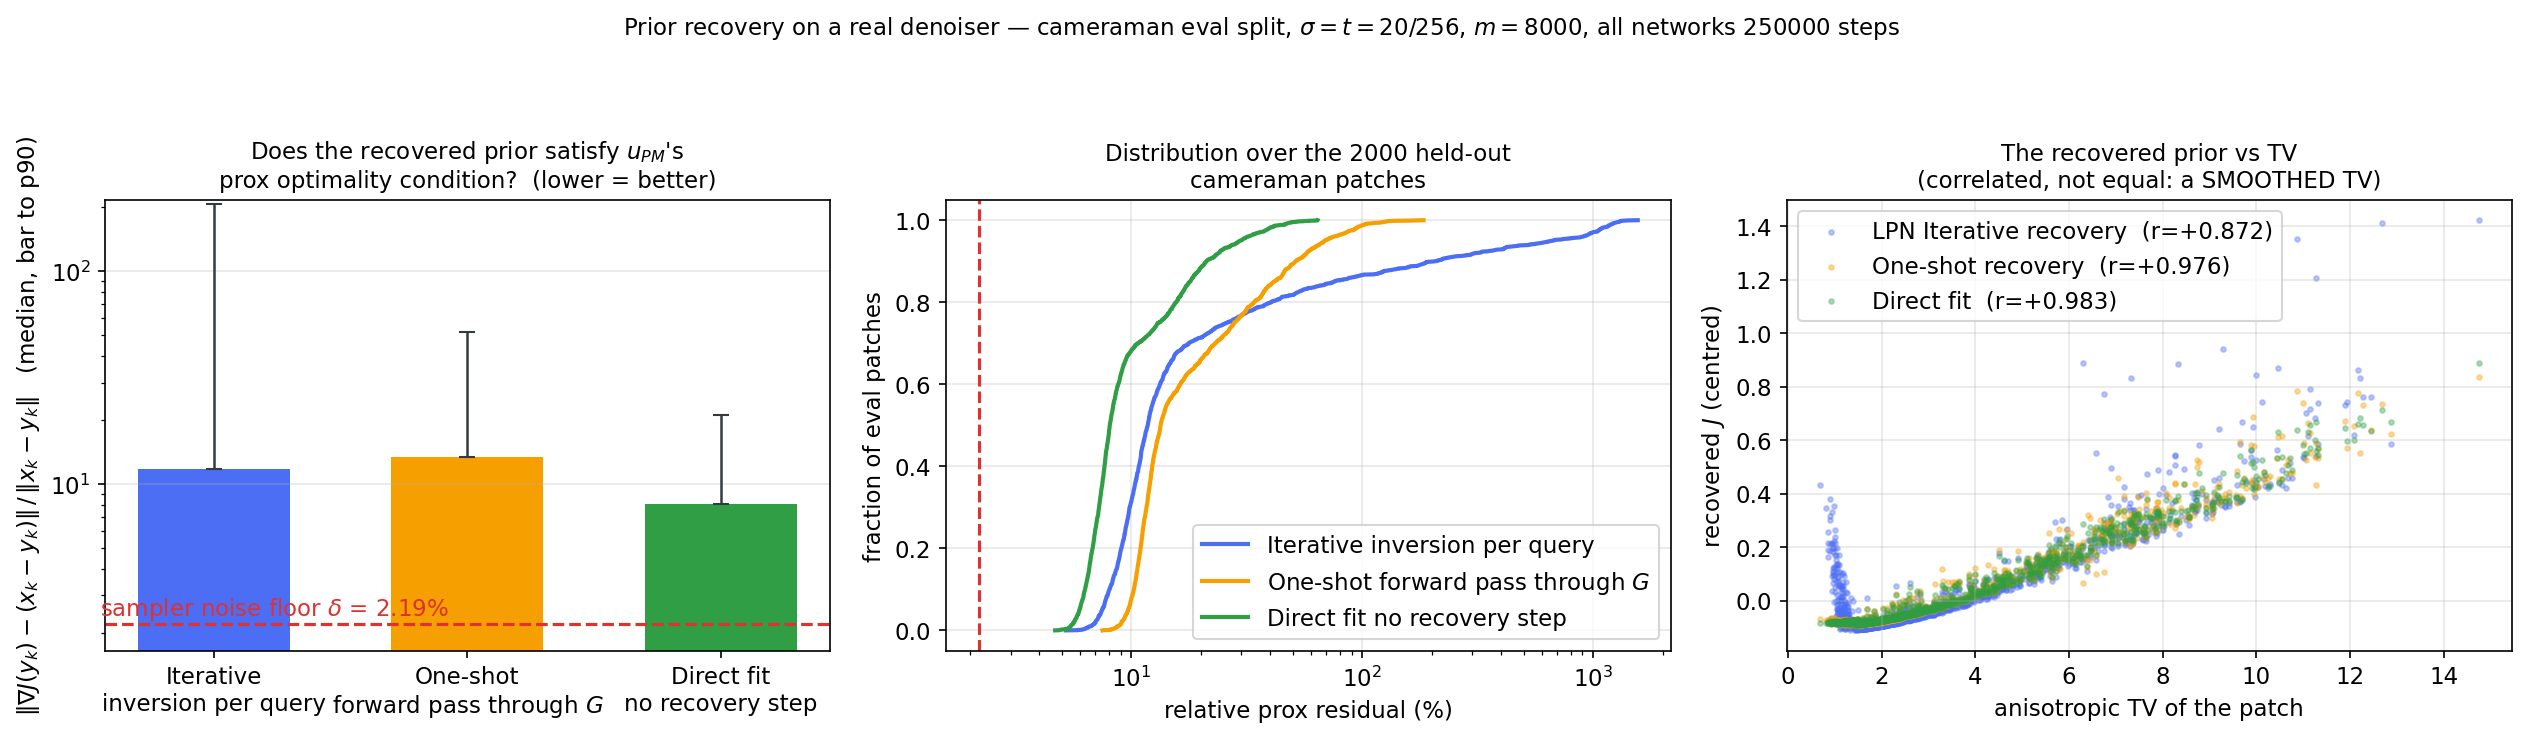

,recovered prior,resid_rel_median_pct,resid_rel_p90_pct,ratio_to_delta,cost
0,LPN Iterative recovery [tripwire],11.787682,206.737311,5.382501,2.5 s (inversion)
1,One-shot recovery,13.396665,51.567965,6.117196,0.00 s (fwd)
2,Direct fit,8.071240,21.190625,3.685496,0.03 s (fwd)


In [25]:
p_fig = os.path.join(TW.FIG_DIR, f"prior_recovery{OUT_TAG}.png")
p_csv = os.path.join(TW.RES_DIR, f"prior_recovery{OUT_TAG}.csv")
assert os.path.exists(p_fig), (
    f"{p_fig} was not written -- the cell above did not finish; read its output "
    f"for the real error rather than this one")
display(Image(filename=p_fig, width=1150))
pd.read_csv(p_csv)

## 4. The prior in action — denoising cameraman

Only two rows are denoisers anyone deploys: $u_{PM}$ and $\nabla\psi_\theta$. Since
$\nabla G=(\nabla\psi)^{-1}$, **neither LPN recovery inverts anything to denoise** —
both deploy $\nabla\psi_\theta$. The $\mathrm{prox}_{J_2}$ panel is a consistency
check: does the prior One-shot recovery *reports* have the denoiser as its prox?

Reference (250k steps): $u_{PM}$ 27.32 dB; $\nabla\psi_\theta$ 26.92 dB / 1.56 % of
$u_{PM}$; **Direct fit 27.09 dB / 0.86 %**.

In [26]:
# In-process, for the same reason as above.
from compare_impl import compare
_ = compare()

image cameraman_256x256_d 256x256, 1024 patches, sigma=0.07812, t=0.07812, lam=0.15625
J_theta checkpoint: tv_pm_64D_fc_m8000_w256_L2_b20.0_s250000_sig0.07812_t0.07812.pth

method                                    PSNR vs clean  SSIM clean  PSNR vs u_PM  rel-L2 %    time s
--------------------------------------------------------------------------------------------------------
noisy input                                       22.50      0.4110          --        --        0.00
u_PM  (MCMC sampler)                              27.32      0.7151          --        --        0.00
u_theta = grad psi  [LPN, both recoveries]          26.90      0.7055         41.47      1.61      0.00
prox of J_2, One-shot recovery  [check]           26.88      0.7030         37.29      2.61      0.27
u_hat  direct = prox J_theta                      27.09      0.7113         46.93      0.86      0.08

consistency-check solve residual : median 3.08e-03, max 2.12e-02
consistency-check diverged patches: 0 / 10

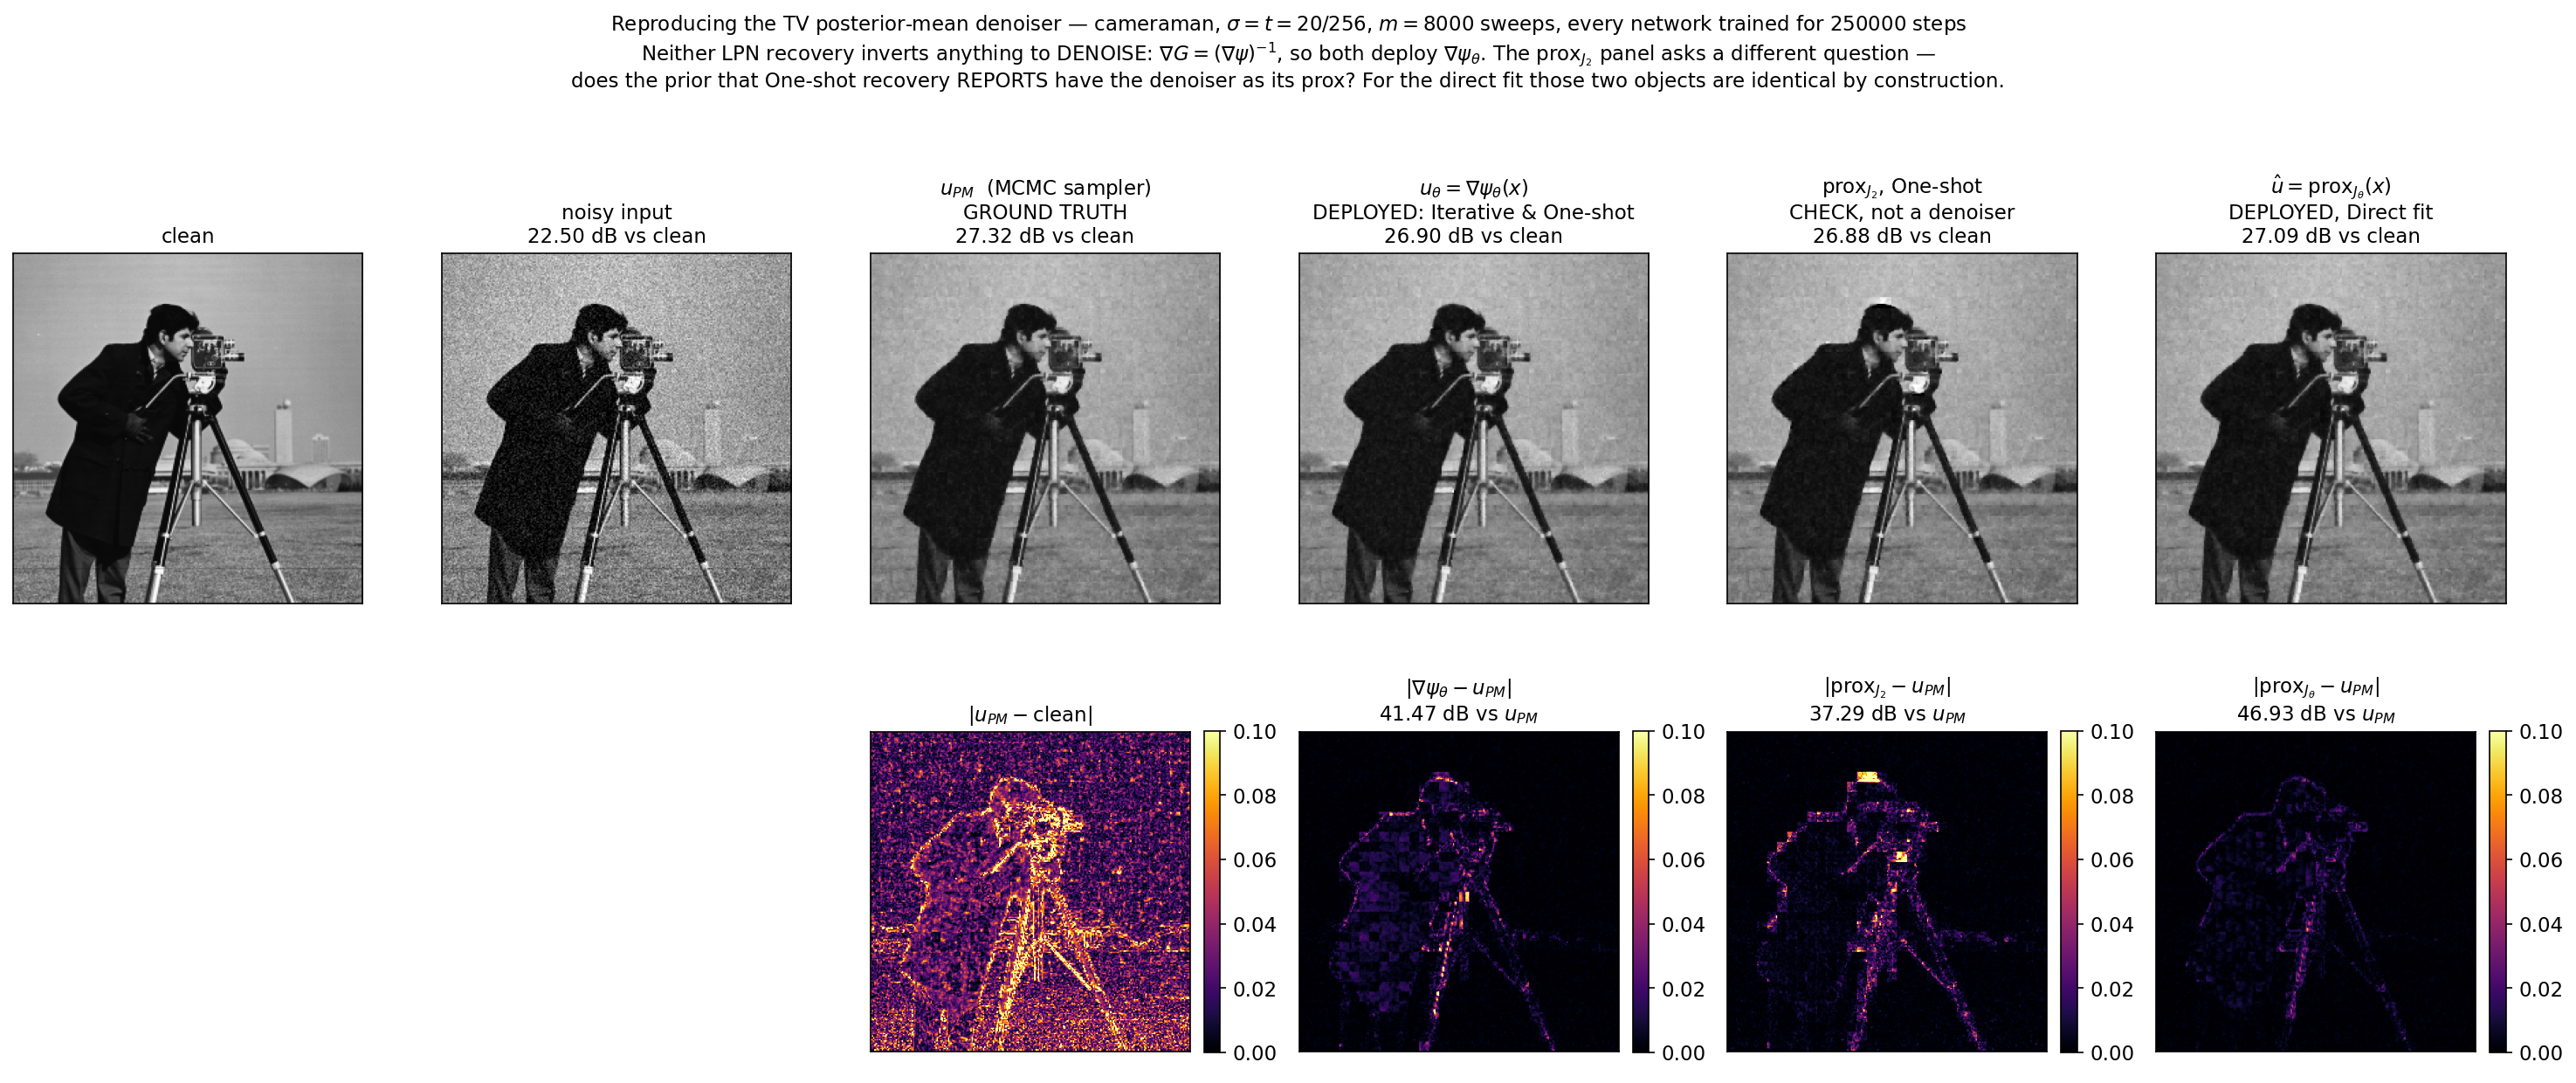

,method,PSNR vs clean (dB),SSIM vs clean,PSNR vs u_PM (dB),SSIM vs u_PM,rel-L2 vs u_PM (%),time (s),note
0,noisy input,22.498639,0.411011,NaN,NaN,NaN,0.000000,sigma = 0.0781
1,u_PM (MCMC sampler),27.322468,0.715094,NaN,NaN,NaN,0.003010,"ground truth, m=8000"
2,"u_theta = grad psi [LPN, both recoveries]",26.903052,0.705506,41.474500,0.995405,1.611494,0.003371,"1 forward pass, no inversion"
3,"prox of J_2, One-shot recovery [check]",26.880812,0.702952,37.285274,0.992838,2.610297,0.265865,"consistency check, not a denoiser"
4,u_hat direct = prox J_theta,27.094874,0.711268,46.933574,0.998199,0.859557,0.084627,recovered prior's prox IS the denoiser


In [27]:
p_fig = os.path.join(TW.FIG_DIR, f"threeway_cameraman{OUT_TAG}.png")
p_csv = os.path.join(TW.RES_DIR, f"threeway_psnr{OUT_TAG}.csv")
assert os.path.exists(p_fig), (
    f"{p_fig} was not written -- the cell above did not finish; read its output "
    f"for the real error rather than this one")
display(Image(filename=p_fig, width=1400))
pd.read_csv(p_csv)